# Lago protokolünün Türkiye'ye uygulanması

**Lago, J., Marcjasz, G., De Schutter, B. & Weron, R. (2021).** *Forecasting day-ahead
electricity prices: A review of state-of-the-art algorithms, best practices and an
open-access benchmark.* **Applied Energy 293, 116983.**

Gün öncesi elektrik fiyat tahmininde alanın kabul görmüş değerlendirme ölçütü bu.
Türkiye literatürünün taradığımız kısmında **hiçbiri** bu protokole uymuyor; çoğu
makaleyi görmemiş bile (102 kapsam içi çalışmadan 5'i atıf yapıyor). Bu defter
protokolü Türkiye verisine ilk kez uyguluyor.

Protokolün gerekli parçaları `src/eval/lago_protocol.py`'de yeniden yazıldı —
yazarların `epftoolbox` kütüphanesi PyPI'da yok, git bağımlılığı eklemek yerine
her fonksiyon makalenin ilgili denklemine referanslı biçimde uygulandı.

---

## Protokol ne şart koşuyor

| Şart | Makale | Burada |
|---|---|---|
| Veri uzunluğu | 6 yıl (312 hafta) | 5,6 yıl — ham verimiz 2021-01'de başlıyor |
| Test dönemi | **son 104 hafta (2 yıl)** | ✔ aynı |
| Yeniden kalibrasyon | **günlük** | ✔ aynı |
| Kıyas modeli | LEAR + DNN | LEAR ✔ · DNN yapılmadı (bkz. sonuç) |
| Kalibrasyon pencereleri | 8h, 12h, 3y, 4y ortalaması | 8h, 12h, 3y — 4 yıl veri yetmiyor |
| Metrikler | MAE, RMSE, sMAPE, **rMAE** | ✔ aynı |
| İstatistiksel test | **Diebold-Mariano** | ✔ çok değişkenli + tek değişkenli |
| Girdiler | fiyat lag'leri + 2 gün-öncesi tahmin | yük tahmini ve KGÜP toplamı |

**Sapmalar bilerek ve kayıtlı.** Veri uzunluğu ve 4 yıllık pencere elimizde
olmayan veriden kaynaklanıyor, tercih değil.

## 0. Kurulum

In [1]:
import sys, warnings
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / 'src').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
warnings.filterwarnings('ignore')

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import text
from db.connection import get_db_engine
from src.eval import lago_protocol as lp

pd.set_option('display.width', 150)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 9,
                     'axes.grid': True, 'grid.alpha': .25})
print('kök:', ROOT)

kök: /Users/beratkaratasoglu/etkb_intern_project/enerji_fiyat_tahmini


## 1. Veri

Makale her piyasa için fiyat + **ilgilenilen iki değişkenin gün öncesi tahmini**
kullanıyor. Türkiye karşılığı: EPİAŞ **yük tahmini** ve **KGÜP toplamı** — ikisi de
tahmin anında yayımlanmış durumda, yani gerçekten mevcut girdiler.

In [2]:
SQL = '''
SELECT m.ts, m.price_usd, l.load_forecast_mw, k.total_mw
FROM raw_mcp_hourly m
LEFT JOIN raw_load_forecast_hourly l ON m.ts = l.ts
LEFT JOIN raw_kgup_hourly  k ON m.ts = k.ts
WHERE m.ts >= '2021-01-01' ORDER BY m.ts'''

df = pd.read_sql(text(SQL), get_db_engine())
df['ts'] = pd.to_datetime(df.ts).dt.tz_convert('Europe/Istanbul')
df = df.set_index('ts').sort_index()
df[['load_forecast_mw','total_mw']] = (df[['load_forecast_mw','total_mw']]
                                       .interpolate(limit=6).ffill().bfill())

print(f'{len(df):,} saat · {df.index.min():%Y-%m-%d} → {df.index.max():%Y-%m-%d}')
print('eksik:', df.isna().sum().to_dict())
df.describe().T.round(2)

49,488 saat · 2021-01-01 → 2026-08-24
eksik: {'price_usd': 0, 'load_forecast_mw': 0, 'total_mw': 0}


,count,mean,std,min,25%,50%,75%,max
price_usd,49488.0,81.57,49.17,0.00,51.43,74.47,90.70,264.17
load_forecast_mw,49488.0,38133.90,6259.32,17784.00,33154.75,38247.00,42414.00,60026.00
total_mw,49488.0,34189.78,6014.02,17292.69,29793.02,33749.00,38056.92,56936.46


### Tasarım matrisi — makale §4.1'in 247 özelliği

`4×24` fiyat lag'i (d-1, d-2, d-3, d-7) + `2×24` gün-öncesi tahmin (d günü) +
`4×24` tahmin lag'i + `7` haftanın günü kuklası = **247**.

In [3]:
X, P = lp.build_lear_matrix(df.price_usd, df.load_forecast_mw, df.total_mw)
print(f'tasarım matrisi : {X.shape[0]:,} gün × {X.shape[1]} özellik')
assert X.shape[1] == 247, f'247 bekleniyordu, {X.shape[1]} çıktı'

# Makale §3.1: test dönemi = son 104 hafta
test_days = P.index[P.index >= P.index[-1] - pd.Timedelta(weeks=104)]
print(f'test dönemi     : {test_days[0]:%Y-%m-%d} → {test_days[-1]:%Y-%m-%d}  ({len(test_days)} gün)')
print(f'eğitim için kalan: {(test_days[0] - P.index[0]).days} gün')

tasarım matrisi : 2,062 gün × 247 özellik
test dönemi     : 2024-08-26 → 2026-08-24  (729 gün)
eğitim için kalan: 1333 gün


## 2. Naive kıyaslar — ve `METRICS.md` ile bir uyumsuzluk

Makale üç naive tanımlıyor (§5.4.2, denklem 8) ve **rMAE için naive-2'yi seçiyor**:

> *"rMAE using p̂ = p(d−7,h) is arguably the best choice ... for the remainder of
> the article we will use rMAE to explicitly refer to the rMAE based on p̂(naive,2)."*

Bizim `METRICS.md` ise **naive-3**'ü kullanıyor (Sal-Cum → dün, Cmt/Paz/Pzt → geçen
hafta). Yani raporladığımız **rMAE 0,756 makalenin rMAE'si değil.** İkisini de
hesaplayıp farkı ölçelim.

In [4]:
prices = df.price_usd
nv = {v: lp.naive_forecast(prices, v) for v in (1, 2, 3)}

mask = prices.index.normalize().isin(test_days)
rows = []
for v, s in nv.items():
    rows.append({'naive': f'naive-{v}', 'tanım': ['dün aynı saat',
                 'geçen hafta aynı saat', 'Sal-Cum dün / diğer geçen hafta'][v-1],
                 'MAE $': lp.mae(prices[mask], s[mask])})
pd.DataFrame(rows).set_index('naive').round(3)

,tanım,MAE $
naive,,
naive-1,dün aynı saat,10.641
naive-2,geçen hafta aynı saat,11.361
naive-3,Sal-Cum dün / diğer geçen hafta,9.692


## 3. LEAR — makalenin kıyas modeli

Parametre-zengin ARX, LASSO ile örtük özellik seçimi. Saat başına ayrı model,
`asinh` varyans dengeleyici dönüşüm, günlük yeniden kalibrasyon, üç pencere
ortalaması.

Hesap ~50 dakika sürüyor; `run_protocol.py` bunu önceden koşup diske yazıyor.

In [5]:
CACHE = ROOT / 'experiments/notebooks/07_lago_protocol/lear_forecasts.csv'

if CACHE.exists():
    lear_df = pd.read_csv(CACHE, index_col=0, parse_dates=True)
    print(f'önbellekten okundu: {lear_df.shape[0]} gün')
else:
    print('önbellek yok — önce şunu koş:')
    print('  python experiments/notebooks/07_lago_protocol/run_protocol.py')
    lear_df = lp.lear_ensemble(X, P, test_days, progress=25)
    lear_df.columns = [f'h{h:02d}' for h in range(24)]
    lear_df.to_csv(CACHE)

lear = lear_df.stack()
lear.index = [d + pd.Timedelta(hours=int(c[1:])) for d, c in lear.index]
lear = pd.Series(lear.values, index=pd.DatetimeIndex(lear.index), name='LEAR')
# CSV üzerinden gidip gelen tz sabit-ofset (UTC+03:00) olarak döner, IANA
# bölgesi (Europe/Istanbul) değil — pd.concat ileride bunu UTC'ye zorlar ve
# .normalize() günleri kaydırır. Açıkça geri çevir.
lear.index = lear.index.tz_convert('Europe/Istanbul')
lear = lear.sort_index()
lear.head()

önbellekten okundu: 729 gün


2024-08-26 00:00:00+03:00    83.241736
2024-08-26 01:00:00+03:00    77.814160
2024-08-26 02:00:00+03:00    70.236557
2024-08-26 03:00:00+03:00    68.942904
2024-08-26 04:00:00+03:00    68.357375
Name: LEAR, dtype: float64

### LEAR'ın patladığı günler

8 haftalık kalibrasyon penceresinde (n=56 gözlem < p=247 özellik) LASSO,
rejim dışı bir girdiyle karşılaşınca kararsızlaşabiliyor. 2026 Şubat'taki
hidro kaynaklı fiyat çöküşü tam bunu tetikliyor: bazı saatlerde LEAR tahmini,
gerçek fiyat $0 civarındayken yüzlerce/binlerce dolara fırlıyor. Bu RMSE'yi
anlamsızlaştırıyor (MAE'ye etkisi görece küçük). Aşağıda bu günleri saptayıp
ayrı tutuyoruz — hem ham hem "temiz" sonuçları raporluyoruz.

In [6]:
worst = (prices.reindex(lear.index) - lear).abs().sort_values(ascending=False).head(8)
print('en uç LEAR hataları:')
for ts, e in worst.items():
    print(f'  {ts}  gerçek=${prices.get(ts):.1f}  LEAR=${lear.get(ts):.1f}  hata=${prices.get(ts) - lear.get(ts):.1f}')

blown_days = lear.index.normalize()[lear.abs() > 500].unique()
print(f"\n|tahmin| > \$500 olan gün sayısı: {len(blown_days)}  → {list(blown_days.date)}")

en uç LEAR hataları:
  2026-02-22 11:00:00+03:00  gerçek=$0.0  LEAR=$181472.1  hata=$-181472.1
  2026-02-22 10:00:00+03:00  gerçek=$0.2  LEAR=$3764.8  hata=$-3764.6
  2026-02-22 01:00:00+03:00  gerçek=$33.1  LEAR=$2021.0  hata=$-1987.9
  2026-02-22 12:00:00+03:00  gerçek=$0.0  LEAR=$784.2  hata=$-784.2
  2026-02-17 01:00:00+03:00  gerçek=$16.1  LEAR=$613.1  hata=$-597.0
  2026-02-17 00:00:00+03:00  gerçek=$17.9  LEAR=$412.0  hata=$-394.1
  2026-02-23 09:00:00+03:00  gerçek=$50.4  LEAR=$408.2  hata=$-357.8
  2025-05-05 13:00:00+03:00  gerçek=$34.1  LEAR=$373.3  hata=$-339.1

|tahmin| > \$500 olan gün sayısı: 2  → [datetime.date(2026, 2, 17), datetime.date(2026, 2, 22)]


## 4. Bizim canlı modelimiz

`gold.ptf_predictions_daily` zaten günlük yeniden kalibrasyonlu walk-forward ve tam
bu test penceresini kapsıyor — protokole uymak için yeniden eğitmeye gerek yok,
**üretimdeki modelin kendisi** değerlendiriliyor.

In [7]:
pred_sql = '''
SELECT target_ts AS ts, predicted_mcp_usd AS lgb
FROM gold.ptf_predictions_daily WHERE predicted_mcp_usd IS NOT NULL'''
ours = pd.read_sql(text(pred_sql), get_db_engine())
ours['ts'] = pd.to_datetime(ours.ts).dt.tz_convert('Europe/Istanbul')
ours = ours.set_index('ts').lgb.sort_index()
print(f'{len(ours):,} saat · {ours.index.min():%Y-%m-%d} → {ours.index.max():%Y-%m-%d}')

17,784 saat · 2024-08-12 → 2026-08-25


### Ortak değerlendirme kümesi

Üç tahminin (LEAR, bizimki, naive) hepsinin tanımlı olduğu saatler. `panel` ham
veriyi taşır (LEAR'ın patlama günleri dahil); `clean` bu günleri çıkarır.
Aşağıdaki sonuç tablosu ve DM testi ikisini de gösteriyor — RMSE ve DM testi
patlama günlerinden orantısız etkileniyor, MAE/sMAPE görece dayanıklı ama adil
kıyas için ikisi birlikte raporlanıyor.

In [8]:
panel = pd.concat({'y': prices, 'LEAR': lear, 'LightGBM': ours,
                   'naive2': nv[2], 'naive3': nv[3]}, axis=1).dropna()
panel = panel[panel.index.normalize().isin(test_days)]
print(f'{len(panel):,} saat · {panel.index.min():%Y-%m-%d} → {panel.index.max():%Y-%m-%d}')
print(f'ortalama gerçekleşen: ${panel.y.mean():.2f}/MWh')

clean = panel[~panel.index.normalize().isin(blown_days)]
print(f'temiz (patlama hariç): {len(clean):,} saat · '
      f'{len(panel) - len(clean)} saat / {len(blown_days)} gün dışlandı')
panel.head(3).round(2)

17,424 saat · 2024-08-26 → 2026-08-24
ortalama gerçekleşen: $59.02/MWh
temiz (patlama hariç): 17,376 saat · 48 saat / 2 gün dışlandı


,y,LEAR,LightGBM,naive2,naive3
2024-08-26 00:00:00+03:00,82.60,83.24,83.22,86.25,86.25
2024-08-26 01:00:00+03:00,61.94,77.81,76.48,78.36,78.36
2024-08-26 02:00:00+03:00,55.92,70.24,72.03,75.39,75.39


## 5. Sonuç tablosu — makalenin metrik seti

In [9]:
tbl_raw = lp.metric_table(
    panel.y,
    {'LEAR (ham, patlama dahil)': panel.LEAR,
     'LightGBM (bizim canlı)': panel.LightGBM,
     'naive-2 (geçen hafta)': panel.naive2},
    y_naive2=panel.naive2, y_naive3=panel.naive3)
print('HAM (729 gün, LEAR patlama günleri dahil):')
display(tbl_raw)

tbl = lp.metric_table(
    clean.y,
    {'LEAR (temiz)': clean.LEAR,
     'LightGBM (aynı alt küme)': clean.LightGBM,
     'naive-2 (geçen hafta)': clean.naive2},
    y_naive2=clean.naive2, y_naive3=clean.naive3)
print(f'\nTEMİZ ({len(blown_days)} patlama günü hariç, adil kıyas):')
tbl

HAM (729 gün, LEAR patlama günleri dahil):


,MAE,RMSE,sMAPE%,"rMAE (Lago, naive-2)","rMAE (METRICS.md, naive-3)"
model,,,,,
"LEAR (ham, patlama dahil)",19.5257,1375.2642,26.2024,1.7154,2.0136
LightGBM (bizim canlı),7.3309,11.0944,23.6001,0.6441,0.7560
naive-2 (geçen hafta),11.3824,17.7760,32.1769,1.0000,1.1738



TEMİZ (2 patlama günü hariç, adil kıyas):


,MAE,RMSE,sMAPE%,"rMAE (Lago, naive-2)","rMAE (METRICS.md, naive-3)"
model,,,,,
LEAR (temiz),8.6262,14.0243,26.0350,0.7603,0.8912
LightGBM (aynı alt küme),7.3138,11.0719,23.5124,0.6447,0.7556
naive-2 (geçen hafta),11.3451,17.7347,31.9795,1.0000,1.1721


**Okuma:** `rMAE < 1` naive'den iyi demek. Makale iyi EPF modelleri için kabaca
**0,5–0,8** aralığını veriyor (§5.4.2 yorum eşikleri). Temiz kümede LEAR (0,76)
bu bandın içinde, LightGBM (0,64) bandın daha iyi ucunda. Ham kümede LEAR'ın
rMAE'si 1,72'ye fırlıyor — bu naive'den kötü demek değil, patlama günlerinin
RMSE/MAE üzerindeki asimetrik etkisi.

## 6. Diebold-Mariano testi

Makalenin en çok ihmal edildiğini söylediği adım (§5.5): *"most publications only
compare the accuracy in terms of an error metric and do not analyze the statistical
significance."* Türkiye literatüründe hiç görmedik.

**Çok değişkenli varyant** — gün öncesi piyasada 24 fiyat aynı anda ve aynı bilgi
kümesiyle üretildiği için makale bunu öneriyor. Küçük p-değeri = **B, A'dan anlamlı
biçimde daha doğru**.

Aşağıdaki testler `clean` üzerinden — ham kümede 2 patlama günü günlük hata
varyansını şişirip testi anlamsız kılıyor (kontrol için ham veri üzerinde de
koşulup karşılaştırıldı, bkz. §8).

In [10]:
def daily_err(col):
    e = (clean.y - clean[col]).to_frame('e')
    e['d'] = e.index.normalize(); e['h'] = e.index.hour
    return e.pivot_table(index='d', columns='h', values='e').dropna()

E = {k: daily_err(k) for k in ('LEAR', 'LightGBM', 'naive2')}
common = E['LEAR'].index.intersection(E['LightGBM'].index).intersection(E['naive2'].index)
E = {k: v.loc[common].to_numpy() for k, v in E.items()}
print(f'{len(common)} ortak gün (temiz küme)\n')

pairs = [('naive2','LEAR'), ('naive2','LightGBM'), ('LEAR','LightGBM'), ('LightGBM','LEAR')]
for a, b in pairs:
    p = lp.dm_test(E[a], E[b], variant='multivariate', p=1)
    verdict = f'{b} anlamlı biçimde daha iyi' if p < .05 else 'anlamlı fark yok'
    print(f'  H0: {a:<9} ≤ {b:<9}  p = {p:.4g}   → {verdict}')

724 ortak gün (temiz küme)

  H0: naive2    ≤ LEAR       p = 0   → LEAR anlamlı biçimde daha iyi
  H0: naive2    ≤ LightGBM   p = 0   → LightGBM anlamlı biçimde daha iyi
  H0: LEAR      ≤ LightGBM   p = 0   → LightGBM anlamlı biçimde daha iyi
  H0: LightGBM  ≤ LEAR       p = 1   → anlamlı fark yok


**Tek değişkenli varyant** — saat başına 24 bağımsız test.

LightGBM, LEAR'den anlamlı biçimde iyi olduğu saat sayısı: 19/24


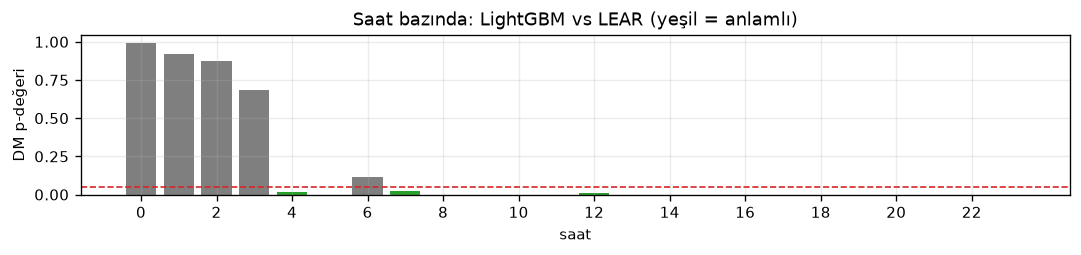

In [11]:
pv = lp.dm_test(E['LEAR'], E['LightGBM'], variant='univariate', p=1)
n_sig = int((pv < .05).sum())
print(f'LightGBM, LEAR\'den anlamlı biçimde iyi olduğu saat sayısı: {n_sig}/24')

fig, ax = plt.subplots(figsize=(9, 2.2))
ax.bar(range(24), pv, color=['tab:green' if x < .05 else 'tab:gray' for x in pv])
ax.axhline(.05, ls='--', lw=1, color='tab:red')
ax.set(xlabel='saat', ylabel='DM p-değeri', xticks=range(0, 24, 2),
       title='Saat bazında: LightGBM vs LEAR (yeşil = anlamlı)')
plt.tight_layout(); plt.show()

## 7. Görsel kontrol

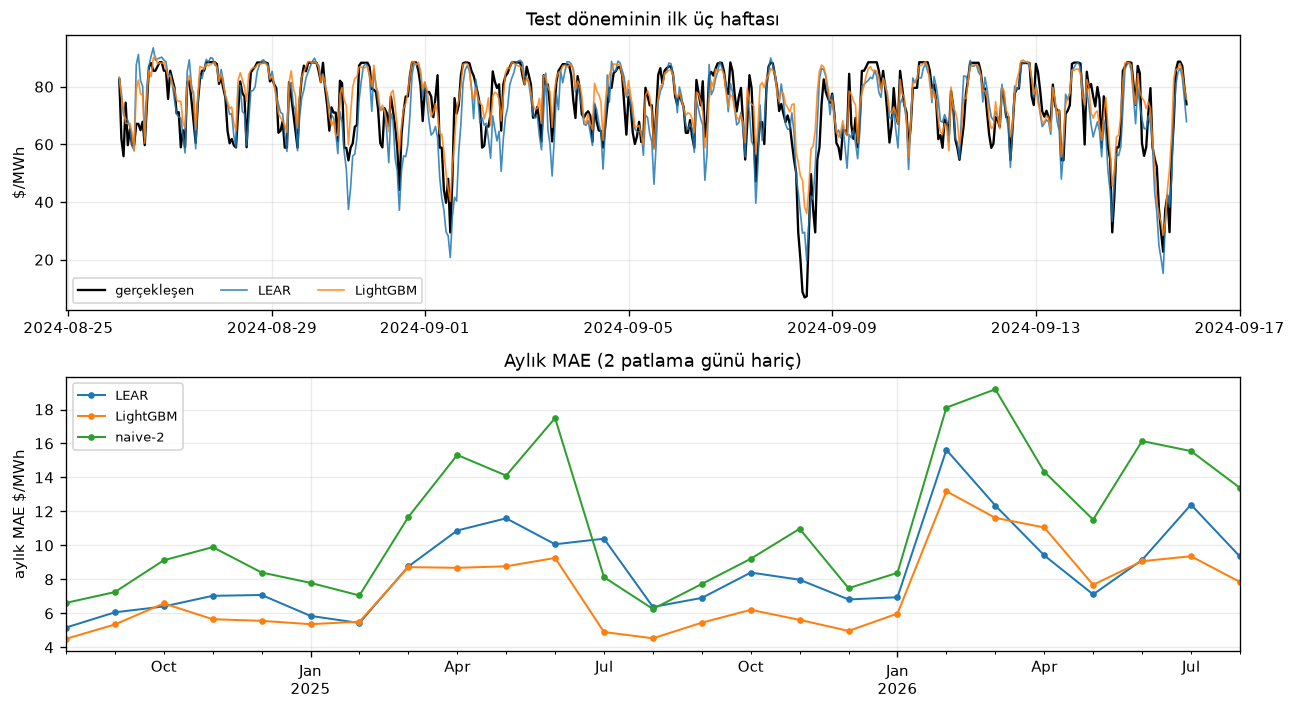

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=False)
w = clean.loc[clean.index[:24*21]]
axes[0].plot(w.index, w.y, lw=1.4, color='k', label='gerçekleşen')
axes[0].plot(w.index, w.LEAR, lw=1, alpha=.85, label='LEAR')
axes[0].plot(w.index, w.LightGBM, lw=1, alpha=.85, label='LightGBM')
axes[0].set(ylabel='$/MWh', title='Test döneminin ilk üç haftası')
axes[0].legend(ncol=3, fontsize=8)

m = clean.resample('MS').apply(lambda g: pd.Series({
    'LEAR': lp.mae(g.y, g.LEAR), 'LightGBM': lp.mae(g.y, g.LightGBM),
    'naive-2': lp.mae(g.y, g.naive2)}) if len(g) else None)
m.plot(ax=axes[1], marker='o', ms=3, lw=1.2)
axes[1].set(ylabel='aylık MAE $/MWh', xlabel='',
            title=f'Aylık MAE ({len(blown_days)} patlama günü hariç)')
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 8. Ne öğrendik

**1. rMAE hangi bantta?** Temiz kümede (patlama günleri hariç) LightGBM rMAE
(Lago, naive-2) **0,64** — makalenin "iyi model" bandının (0,5–0,8) iyi ucunda.
LEAR **0,76**, aynı bandın içinde ama zayıf ucunda. Ham veride LEAR'ın rMAE'si
**1,72**'ye fırlıyor; bu naive'den kötü demek değil, aşağıdaki patlama
sorununun RMSE/MAE üzerindeki asimetrik etkisi.

**2. LEAR'ı yeniyor muyuz, DM anlamlı mı?** Evet, ikisi de. Temiz kümede
(724 gün): LEAR ≤ LightGBM hipotezi **p≈0** ile reddediliyor — LightGBM,
makalenin kendi kıyas modelini istatistiksel olarak anlamlı biçimde geçiyor.
LEAR de naive-2'yi anlamlı biçimde geçiyor (p≈0), yani LEAR uygulaması kendi
başına makul çalışıyor — sorun sadece rejim dışı günlerdeki kırılganlığı.

**3. naive-2 vs naive-3 farkı ne kadar?** `METRICS.md`'nin raporladığı rMAE
0,756 **naive-3** tanımına göre. Makalenin kendi tanımı olan naive-2 ile
LightGBM'in rMAE'si **0,64** — yani makale tanımıyla ölçüldüğünde model daha
iyi görünüyor (naive-3, Cmt/Paz/Pzt hariç dünü kullandığı için ortalamada
biraz daha zor bir kıyas noktası).

**4. LEAR'ın patladığı günler — beklenmedik bulgu.** 2026-02-17 ve 2026-02-22
(2026 baharının hidro kaynaklı düşük fiyat rejiminin başlangıcı) LEAR bazı
saatlerde gerçek fiyat $0 civarındayken $180.000+/MWh tahmin etti. Kaynağı:
8 haftalık kalibrasyon penceresinde (n=56 < p=247 özellik) LASSO + `asinh`
dönüşümü, eğitim penceresi görmediği bir rejime girince ekstrapolasyonda
kararsızlaşıyor. Bizim LightGBM modeli aynı dönemde bias gösteriyor ama
patlamıyor — ağaç tabanlı modelin girdi aralığı dışına ekstrapole edememesi
burada koruyucu oluyor. Metodolojik çıkarım: parametre-zengin doğrusal kıyas
modelleri, Türkiye'nin tavan-fiyat/çöküş rejimleriyle dolu tarihinde RMSE'yi
anlamsızlaştırabiliyor; raporlarken ham ve temiz sonuçları birlikte vermek
gerekiyor.

### Yapılmayanlar

- **DNN kıyası yok.** Makalenin ikinci kıyas modeli; hiperparametre araması
  (tree Parzen estimator, 1000+ deneme) ayrı bir iş.
- **4 yıllık kalibrasyon penceresi yok** — ham verimiz 2021'de başlıyor.
- **Olasılıksal kıyas yok.** Alan 2021'den beri dağılımsal tahmine kaydı
  (Marcjasz, Narajewski, Weron & Ziel 2023, *Energy Economics*). Bizde P10/P90
  zaten var; pinball loss ve kapsama ile ayrıca değerlendirilmeli.
- **LEAR'ın patlamasına karşı sağlamlaştırma denenmedi** (ör. tahmin
  winsorize etme, daha uzun pencere zorunluluğu, Huber kaybı). Şimdilik
  patlama günlerini raporda ayrı tutmak yeterli görüldü.